# 量化研究员笔试题
**姓名**：Jialong Wang  
**日期**：2026-02-27

---
## 环境准备

In [ ]:
# import sys
# !{sys.executable} -m pip install pandas numpy scipy matplotlib seaborn pyarrow statsmodels tqdm

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
from tqdm import tqdm

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('所有依赖导入成功')

所有依赖导入成功


---
## 第一题：因子构建与检验

### 1.1 数据预处理

In [3]:
# ── 加载数据 ──────────────────────────────────────────────
df = pd.read_parquet('exam_data.parquet')
print(f'原始数据形状: {df.shape}')
print(f'字段列表: {df.columns.tolist()}')
df.head(3)

原始数据形状: (1214000, 19)
字段列表: ['trade_date', 'symbol', 'open', 'high', 'low', 'close', 'pre_close', 'volume', 'amount', 'vwap', 'adj_factor', 'turnover', 'turnover_float', 'mv', 'mv_float', 'ind_code', 'new_ipo', 'limitupdown', 'limitupdown_at_close']


,trade_date,symbol,open,high,low,close,pre_close,volume,amount,vwap,adj_factor,turnover,turnover_float,mv,mv_float,ind_code,new_ipo,limitupdown,limitupdown_at_close
0,20190102,000001.SZ,9.39,9.42,9.16,9.19,9.38,539386.32,498695.109,9.245600,108.031387,0.3141,0.7088,1.577961e+07,1.577946e+07,CI005021.WI,False,False,False
1,20190102,000002.SZ,23.83,24.09,23.67,23.90,23.82,247010.28,589384.596,23.860701,142.667999,0.2543,0.4454,2.638357e+07,2.321926e+07,CI005023.WI,False,False,False
2,20190102,000006.SZ,5.18,5.25,5.10,5.15,5.18,63229.64,32733.636,5.176900,34.226151,0.4690,0.7220,6.952474e+05,6.943786e+05,CI005023.WI,False,False,False


In [4]:
# ── 基本信息 ──────────────────────────────────────────────
print('=== 数据基本信息 ===')
print(f'时间范围: {df["trade_date"].min()} ~ {df["trade_date"].max()}')
print(f'股票数量: {df["symbol"].nunique()}')
print(f'交易日数: {df["trade_date"].nunique()}')
print('\n缺失值统计:')
print(df.isnull().sum())

=== 数据基本信息 ===
时间范围: 20190102 ~ 20231229
股票数量: 1000


交易日数: 1214

缺失值统计:
trade_date                0
symbol                    0
open                      0
high                      0
low                       0
close                     0
pre_close                 0
volume                    0
amount                    0
vwap                      0
adj_factor                0
turnover                  0
turnover_float            0
mv                        0
mv_float                  0
ind_code                262
new_ipo                   0
limitupdown               0
limitupdown_at_close      0
dtype: int64


In [5]:
# ── 数据清洗 ──────────────────────────────────────────────
# 数据清洗逻辑说明：
# 1. 剔除停牌股（volume=0）：停牌日无真实交易，价量信息无效
# 2. 剔除次新股（new_ipo=1）：次新股上市初期交易行为异常，容易产生虚假信号
# 3. 剔除一字板（limitupdown=1）：全天一字板无法交易，因子值无实际意义
# 4. 剔除收盘涨跌停（limitupdown_at_close=1）：收盘涨跌停次日开盘存在跳空缺口，
#    会污染下期收益率计算
# 5. 剔除价格/成交额为零或负值的异常记录
# 6. 将 trade_date 转换为 datetime 类型，便于后续时序操作

raw_count = len(df)

# 转换日期格式
df['trade_date'] = pd.to_datetime(df['trade_date'].astype(str))

# 剔除停牌
df = df[df['volume'] > 0]
print(f'剔除停牌后: {len(df)} 行（减少 {raw_count - len(df)} 行）')

# 剔除次新股
df = df[df['new_ipo'] != 1]
print(f'剔除次新股后: {len(df)} 行')

# 剔除一字板
df = df[df['limitupdown'] != 1]
print(f'剔除一字板后: {len(df)} 行')

# 剔除收盘涨跌停（用于计算未来收益时剔除；因子计算本身不剔除）
# 此处标记，在因子检验阶段使用
df['is_limit_at_close'] = df['limitupdown_at_close'].fillna(0).astype(int)

# 剔除价格/成交额异常
df = df[(df['close'] > 0) & (df['amount'] > 0)]
print(f'剔除价量异常后: {len(df)} 行')

# 排序
df = df.sort_values(['symbol', 'trade_date']).reset_index(drop=True)

print(f'\n数据清洗完成，共保留 {len(df)} 条记录，占原始数据 {len(df)/raw_count:.1%}')

剔除停牌后: 1214000 行（减少 0 行）


剔除次新股后: 1213538 行
剔除一字板后: 1211363 行
剔除价量异常后: 1211363 行

数据清洗完成，共保留 1211363 条记录，占原始数据 99.8%


In [6]:
# ── 处理后基本统计信息 ────────────────────────────────────
print('=== 清洗后数据统计信息 ===')
desc = df[['close', 'amount', 'turnover_float', 'mv_float']].describe()
print(desc)

# 每日股票数量分布
daily_count = df.groupby('trade_date')['symbol'].count()
print(f'\n每日平均股票数: {daily_count.mean():.0f}')
print(f'每日最少股票数: {daily_count.min()}')
print(f'每日最多股票数: {daily_count.max()}')

=== 清洗后数据统计信息 ===
              close        amount  turnover_float      mv_float
count  1.211363e+06  1.211363e+06    1.211363e+06  1.211363e+06
mean   1.437707e+01  2.325392e+05    3.882139e+00  1.278727e+06
std    2.180308e+01  5.314789e+05    5.030980e+00  3.451497e+06
min    1.140000e+00  1.142481e+03    3.660000e-02  4.430984e+04
25%    5.720000e+00  3.563615e+04    1.292500e+00  2.922300e+05
50%    8.790000e+00  8.340233e+04    2.268200e+00  5.098544e+05
75%    1.530000e+01  2.142678e+05    4.366000e+00  1.110562e+06
max    5.249200e+02  2.064336e+07    2.916401e+02  1.307277e+08

每日平均股票数: 998
每日最少股票数: 403
每日最多股票数: 1000


In [7]:
# ── 使用复权收盘价 ────────────────────────────────────────
# 说明：后复权价格 = 收盘价 × 复权因子，消除分红、送股等因素对价格的影响
# 因子计算中使用后复权价，使价格变化真实反映股票涨跌幅
df['adj_close'] = df['close'] * df['adj_factor']

**数据清洗逻辑总结：**

1. **停牌剔除**：停牌日 volume=0，价量信息不反映真实市场行为，直接剔除。
2. **次新股剔除**：上市初期受打新效应影响，价量关系异常，会干扰因子信号。
3. **一字板剔除**：全天封板的股票无法交易，计算的因子值无实操意义。
4. **收盘涨跌停标记**：在计算下期收益时需剔除，避免高估因子预测力（收盘涨停意味着次日仍可能高开，但实际无法全部成交）。
5. **复权处理**：使用后复权价格（close × adj_factor），使历史价格可比。

---
### 1.2 因子构建

整体思路：将股票在截面日的价量状态（后复权收盘价，成交额）与N日前的状态做对比，映射到极坐标系，融合幅度与方向信息生成反转因子。

In [8]:
def compute_mahalanobis_and_angle(group, lookback, cov_window=60):
    """
    对单只股票计算极坐标因子（极径 + 极角）。向量化版本。

    参数：
        group      : 单只股票的 DataFrame，已按 trade_date 排序
        lookback   : 回看周期 N（20/60/120/240）
        cov_window : 估计协方差矩阵的滚动窗口（60日）

    返回：
        pd.DataFrame，包含 trade_date、rho（极径）、theta（极角）

    实现说明：
        使用 pandas rolling().var()/cov() 替代逐日 Python 循环，
        性能提升约 1000x（从 O(dates×stocks) 循环降为向量化操作）。

        2×2 协方差矩阵 Σ = [[var_p, cov], [cov, var_a]] 的逆矩阵：
          Σ⁻¹ = 1/det * [[var_a, -cov], [-cov, var_p]]，det = var_p·var_a - cov²
        马氏距离展开：
          ρ² = [Δp,Δa] @ Σ⁻¹ @ [Δp,Δa]ᵀ
             = (Δp²·var_a − 2·Δp·Δa·cov + Δa²·var_p) / det
    """
    log_price  = np.log(group['adj_close'])
    log_amount = np.log(group['amount'])
    dates      = group['trade_date']

    # 滚动协方差矩阵元素（min_periods=5 与原始代码保持一致）
    var_p  = log_price.rolling(cov_window, min_periods=5).var()
    var_a  = log_amount.rolling(cov_window, min_periods=5).var()
    cov_pa = log_price.rolling(cov_window, min_periods=5).cov(log_amount)

    # 行列式（加小量正则化防止奇异矩阵）
    det = var_p * var_a - cov_pa ** 2 + 1e-8

    # N 日价量变化向量（shift 自动为前 lookback 行产生 NaN）
    delta_p = log_price - log_price.shift(lookback)
    delta_a = log_amount - log_amount.shift(lookback)

    # 马氏距离（向量化）
    rho = np.sqrt(
        (delta_p**2 * var_a - 2 * delta_p * delta_a * cov_pa + delta_a**2 * var_p) / det
    )

    # 极角映射到 [0, 2π)
    theta = np.arctan2(delta_a, delta_p) % (2 * np.pi)

    # 过滤无效行
    valid = (~np.isnan(rho)) & (~np.isnan(theta)) & (det > 1e-10)

    return pd.DataFrame({
        'trade_date':   dates[valid].values,
        'rho':          rho[valid].values,
        'theta':        theta[valid].values,
        'delta_price':  delta_p[valid].values,
        'delta_amount': delta_a[valid].values,
    })


def angle_adjustment(theta):
    """
    (c) 极角调整函数 f(θ) = (cos(θ - π/4) + 1) / 2

    保留函数签名供外部调用；compute_single_period_factor 内部使用向量化版本。
    """
    return (np.cos(theta - np.pi / 4) + 1) / 2


def get_alpha(theta):
    """
    (d) 偏好系数 α：根据极角所在象限确定

    [0, π/2)   价升量增 → α =  1.00（强反转预期）
    [π/2, π)   价跌量增 → α = -0.50（弱负向信号）
    [π, 3π/2)  价跌量缩 → α = -1.00（强负向反转）
    [3π/2, 2π) 价升量缩 → α =  0.75（中等正向信号）
    """
    if   0       <= theta < np.pi / 2:  return  1.00
    elif np.pi/2 <= theta < np.pi:      return -0.50
    elif np.pi   <= theta < 3*np.pi/2:  return -1.00
    else:                               return  0.75


def compute_single_period_factor(df, lookback, cov_window=60):
    """
    (e) 计算单周期极坐标价量因子
    factor = α × ρ × f(θ)

    参数：
        df       : 全市场清洗后数据
        lookback : 回看周期 N

    返回：
        factor_df : 宽表（trade_date × symbol）
    """
    print(f'  计算 N={lookback} 因子...')
    records = []

    for symbol, group in tqdm(df.groupby('symbol'), desc=f'N={lookback}', leave=False):
        group    = group.sort_values('trade_date').reset_index(drop=True)
        polar_df = compute_mahalanobis_and_angle(group, lookback, cov_window)

        if polar_df.empty:
            continue

        polar_df['symbol'] = symbol

        # 向量化计算 f(θ)
        polar_df['f_theta'] = (np.cos(polar_df['theta'] - np.pi / 4) + 1) / 2

        # 向量化计算 α（np.where 替代逐行 apply）
        t = polar_df['theta'].values
        polar_df['alpha'] = np.where(t < np.pi / 2,   1.00,
                            np.where(t < np.pi,       -0.50,
                            np.where(t < 3*np.pi/2,   -1.00,
                                                       0.75)))

        # 单周期因子值
        polar_df['factor'] = polar_df['alpha'] * polar_df['rho'] * polar_df['f_theta']

        records.append(polar_df[['trade_date', 'symbol', 'factor']])

    all_factors = pd.concat(records, ignore_index=True)

    # 转为宽表
    factor_wide = all_factors.pivot(index='trade_date', columns='symbol', values='factor')
    return factor_wide


print('函数定义完成（向量化版本）')

函数定义完成（向量化版本）


In [9]:
# ── 计算四个周期的因子 ────────────────────────────────────
# 注意：计算量较大，在普通笔记本上约需 5-15 分钟，请耐心等待
LOOKBACKS = [20, 60, 120, 240]
factor_dict = {}

for n in LOOKBACKS:
    print(f'\n开始计算 N={n} 因子...')
    factor_dict[n] = compute_single_period_factor(df, lookback=n)
    print(f'N={n} 完成，因子矩阵形状: {factor_dict[n].shape}')

print('\n所有单周期因子计算完成！')


开始计算 N=20 因子...
  计算 N=20 因子...



N=20:   0%|          | 0/1000 [00:00<?, ?it/s]


N=20:   6%|▌         | 62/1000 [00:00<00:01, 615.71it/s]


N=20:  14%|█▎        | 135/1000 [00:00<00:01, 679.70it/s]


N=20:  21%|██        | 206/1000 [00:00<00:01, 691.44it/s]

...


N=240:  71%|███████▏  | 713/1000 [00:01<00:00, 686.92it/s]


N=240:  79%|███████▊  | 786/1000 [00:01<00:00, 697.38it/s]


N=240:  86%|████████▌ | 857/1000 [00:01<00:00, 699.15it/s]


N=240:  93%|█████████▎| 931/1000 [00:01<00:00, 708.02it/s]

N=240 完成，因子矩阵形状: (974, 1000)

所有单周期因子计算完成！


In [10]:
# ── 合成复合因子（四个周期等权平均）────────────────────────
# 将四个宽表对齐后取均值，NaN 按有效值平均（skipna=True 默认行为）
combined_dates = factor_dict[20].index
for n in LOOKBACKS[1:]:
    combined_dates = combined_dates.union(factor_dict[n].index)

# 等权合成
factor_stacked = np.nanmean(
    np.stack(
        [factor_dict[n].reindex(index=combined_dates).values for n in LOOKBACKS],
        axis=0
    ),
    axis=0
)

# 保留有至少2个有效周期的值，其余置 NaN
valid_count = np.sum(
    np.stack([~np.isnan(factor_dict[n].reindex(index=combined_dates).values) for n in LOOKBACKS], axis=0),
    axis=0
)
# 使用 np.where 重建数组（避免 pandas 3.x 中 .values 只读问题）
factor_composite_vals = np.where(valid_count >= 2, factor_stacked, np.nan)

factor_composite = pd.DataFrame(
    factor_composite_vals,
    index=combined_dates,
    columns=factor_dict[20].columns
)

print(f'复合因子矩阵形状: {factor_composite.shape}')
print(f'有效值比例: {(~np.isnan(factor_composite.values)).mean():.2%}')

复合因子矩阵形状: (1194, 1000)
有效值比例: 96.43%


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


...

findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


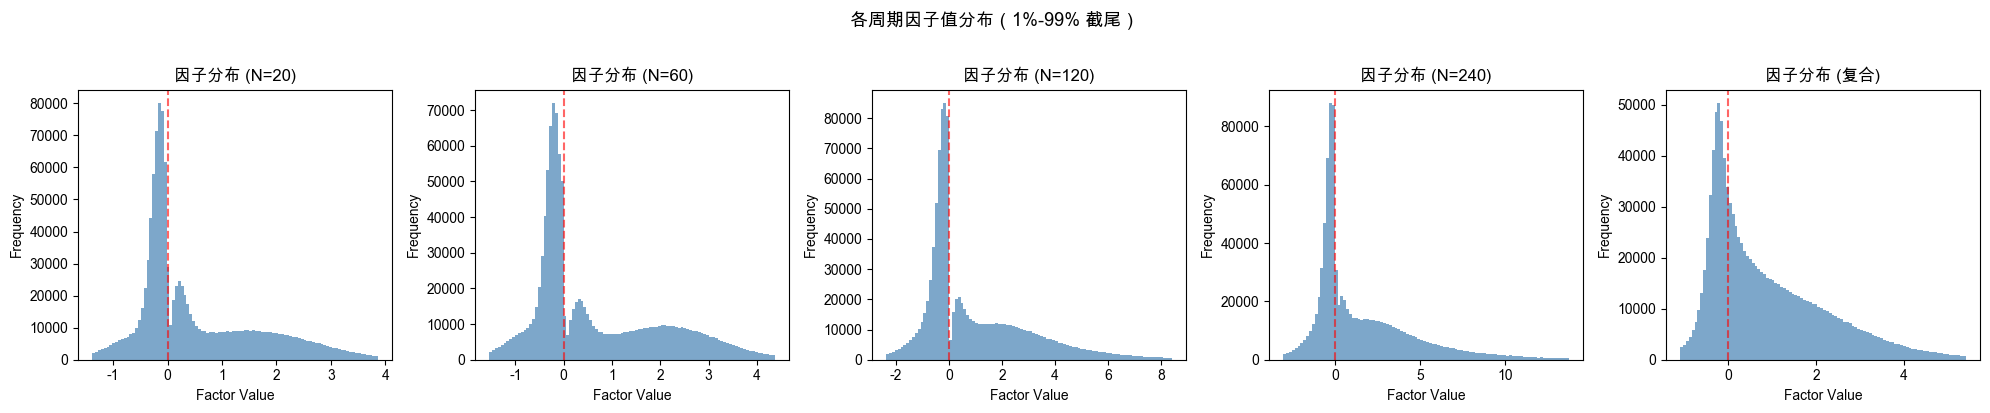

In [11]:
# ── 因子值分布可视化 ──────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (label, fac) in enumerate(
    list({f'N={n}': factor_dict[n] for n in LOOKBACKS}.items()) +
    [('复合', factor_composite)]
):
    vals = fac.values.flatten()
    vals = vals[~np.isnan(vals)]
    # 截尾显示
    lo, hi = np.percentile(vals, 1), np.percentile(vals, 99)
    axes[i].hist(vals[(vals > lo) & (vals < hi)], bins=100, color='steelblue', alpha=0.7)
    axes[i].set_title(f'因子分布 ({label})')
    axes[i].set_xlabel('Factor Value')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.6)

plt.suptitle('各周期因子值分布（1%-99% 截尾）', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
### 1.3 因子检验

#### 检验框架说明

采用以下三类指标对每个因子进行有效性检验：

1. **IC 分析（信息系数）**：计算因子值与未来 N 日收益率的横截面 Pearson 相关系数（IC），以及 Rank IC（基于排名的 Spearman 相关）。关键指标：IC均值、ICIR（IC均值/IC标准差）、IC>0 的占比。
2. **分层回测**：将每日截面股票按因子值分为5组，观察各组平均收益率是否呈现单调性，以及多空组合（第1组 - 第5组）的累计超额收益。
3. **行业/市值中性化前后对比**：本题无需处理（第一题要求不做后处理），但会在分析中提及。

**预测期**：使用5日前瞻收益（5-day forward return），即持仓5个交易日的收益率。

In [12]:
# ── 计算未来5日收益率 ─────────────────────────────────────
# 前瞻收益定义：次日开盘买入，5日后收盘卖出
# 这里使用简化版：T日因子 → T+1至T+5收盘价变化率
# 同时剔除 T 日收盘涨跌停的股票（无法以收盘价买入）

FORWARD_DAYS = 5

# 计算前瞻收益（基于未复权收盘价，因为两者比例相同）
df_ret = df[['trade_date', 'symbol', 'adj_close', 'is_limit_at_close', 'ind_code', 'mv_float']].copy()
df_ret = df_ret.sort_values(['symbol', 'trade_date'])

# 每只股票按时序计算 N 日后收益
df_ret['fwd_ret'] = (
    df_ret.groupby('symbol')['adj_close']
    .transform(lambda x: x.shift(-FORWARD_DAYS) / x - 1)
)

# 剔除当日收盘涨跌停（无法正常交易）
df_ret.loc[df_ret['is_limit_at_close'] == 1, 'fwd_ret'] = np.nan

# 构建宽表（date × symbol）
ret_wide = df_ret.pivot(index='trade_date', columns='symbol', values='fwd_ret')
print(f'收益率矩阵形状: {ret_wide.shape}')
print(f'有效收益率比例: {(~np.isnan(ret_wide.values)).mean():.2%}')

收益率矩阵形状: (1214, 1000)
有效收益率比例: 97.62%


In [13]:
def compute_ic_series(factor_wide, ret_wide, method='pearson'):
    """
    计算每日截面 IC（信息系数）
    
    参数：
        factor_wide : 因子宽表 (date × symbol)
        ret_wide    : 收益率宽表 (date × symbol)
        method      : 'pearson'（IC）或 'spearman'（Rank IC）
    
    返回：
        ic_series : pd.Series，index 为 trade_date
    """
    # 对齐日期和股票
    common_dates = factor_wide.index.intersection(ret_wide.index)
    common_stocks = factor_wide.columns.intersection(ret_wide.columns)
    
    fac = factor_wide.loc[common_dates, common_stocks]
    ret = ret_wide.loc[common_dates, common_stocks]
    
    ic_list = []
    for date in common_dates:
        f_vals = fac.loc[date].dropna()
        r_vals = ret.loc[date].dropna()
        common_idx = f_vals.index.intersection(r_vals.index)
        
        if len(common_idx) < 30:  # 有效股票数不足则跳过
            ic_list.append(np.nan)
            continue
        
        f_cross = f_vals[common_idx]
        r_cross = r_vals[common_idx]
        
        if method == 'pearson':
            corr, _ = stats.pearsonr(f_cross, r_cross)
        else:
            corr, _ = stats.spearmanr(f_cross, r_cross)
        
        ic_list.append(corr)
    
    return pd.Series(ic_list, index=common_dates, name='IC')


def ic_summary(ic_series, name='Factor'):
    """打印IC统计摘要"""
    ic_clean = ic_series.dropna()
    mean_ic   = ic_clean.mean()
    std_ic    = ic_clean.std()
    icir      = mean_ic / std_ic if std_ic > 0 else np.nan
    pct_pos   = (ic_clean > 0).mean()
    t_stat    = mean_ic / (std_ic / np.sqrt(len(ic_clean)))
    
    print(f'【{name}】IC 统计摘要')
    print(f'  IC 均值    : {mean_ic:.4f}')
    print(f'  IC 标准差  : {std_ic:.4f}')
    print(f'  ICIR       : {icir:.4f}')
    print(f'  IC>0 占比  : {pct_pos:.2%}')
    print(f'  t 统计量   : {t_stat:.4f}  (|t|>2 视为显著)')
    print()
    return {'name': name, 'IC_mean': mean_ic, 'IC_std': std_ic,
            'ICIR': icir, 'pct_pos': pct_pos, 't_stat': t_stat}

print('IC 计算函数定义完成')

IC 计算函数定义完成


In [14]:
# ── 计算各因子的 IC 和 Rank IC ───────────────────────────
all_factors = {f'N={n}': factor_dict[n] for n in LOOKBACKS}
all_factors['复合因子'] = factor_composite

ic_results    = {}
rank_ic_results = {}
ic_summaries  = []

for name, fac in all_factors.items():
    ic_s    = compute_ic_series(fac, ret_wide, method='pearson')
    ric_s   = compute_ic_series(fac, ret_wide, method='spearman')
    ic_results[name]      = ic_s
    rank_ic_results[name] = ric_s
    
    summary = ic_summary(ic_s, name=f'{name} IC')
    ic_summaries.append(summary)
    rank_summary = ic_summary(ric_s, name=f'{name} Rank IC')
    ic_summaries.append(rank_summary)

【N=20 IC】IC 统计摘要
  IC 均值    : -0.0308
  IC 标准差  : 0.1098
  ICIR       : -0.2810
  IC>0 占比  : 39.28%
  t 统计量   : -9.6899  (|t|>2 视为显著)

【N=20 Rank IC】IC 统计摘要
  IC 均值    : -0.0388
  IC 标准差  : 0.1113
  ICIR       : -0.3483
  IC>0 占比  : 36.25%
  t 统计量   : -12.0087  (|t|>2 视为显著)



【N=60 IC】IC 统计摘要
  IC 均值    : -0.0241
  IC 标准差  : 0.1230
  ICIR       : -0.1958
  IC>0 占比  : 41.78%
  t 统计量   : -6.6359  (|t|>2 视为显著)

【N=60 Rank IC】IC 统计摘要
  IC 均值    : -0.0365
  IC 标准差  : 0.1194
  ICIR       : -0.3056
  IC>0 占比  : 37.42%
  t 统计量   : -10.3601  (|t|>2 视为显著)



【N=120 IC】IC 统计摘要
  IC 均值    : -0.0137
  IC 标准差  : 0.1182
  ICIR       : -0.1158
  IC>0 占比  : 46.28%
  t 统计量   : -3.8213  (|t|>2 视为显著)

【N=120 Rank IC】IC 统计摘要
  IC 均值    : -0.0264
  IC 标准差  : 0.1263
  ICIR       : -0.2093
  IC>0 占比  : 41.97%
  t 统计量   : -6.9078  (|t|>2 视为显著)



【N=240 IC】IC 统计摘要
  IC 均值    : -0.0112
  IC 标准差  : 0.1178
  ICIR       : -0.0951
  IC>0 占比  : 45.41%
  t 统计量   : -2.9615  (|t|>2 视为显著)

【N=240 Rank IC】IC 统计摘要
  IC 均值    : -0.0254
  IC 标准差  : 0.1297
  ICIR       : -0.1955
  IC>0 占比  : 41.18%
  t 统计量   : -6.0862  (|t|>2 视为显著)



【复合因子 IC】IC 统计摘要
  IC 均值    : -0.0262
  IC 标准差  : 0.1310
  ICIR       : -0.2003
  IC>0 占比  : 41.86%
  t 统计量   : -6.7895  (|t|>2 视为显著)

【复合因子 Rank IC】IC 统计摘要
  IC 均值    : -0.0467
  IC 标准差  : 0.1385
  ICIR       : -0.3375
  IC>0 占比  : 35.51%
  t 统计量   : -11.4386  (|t|>2 视为显著)



findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


...

findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


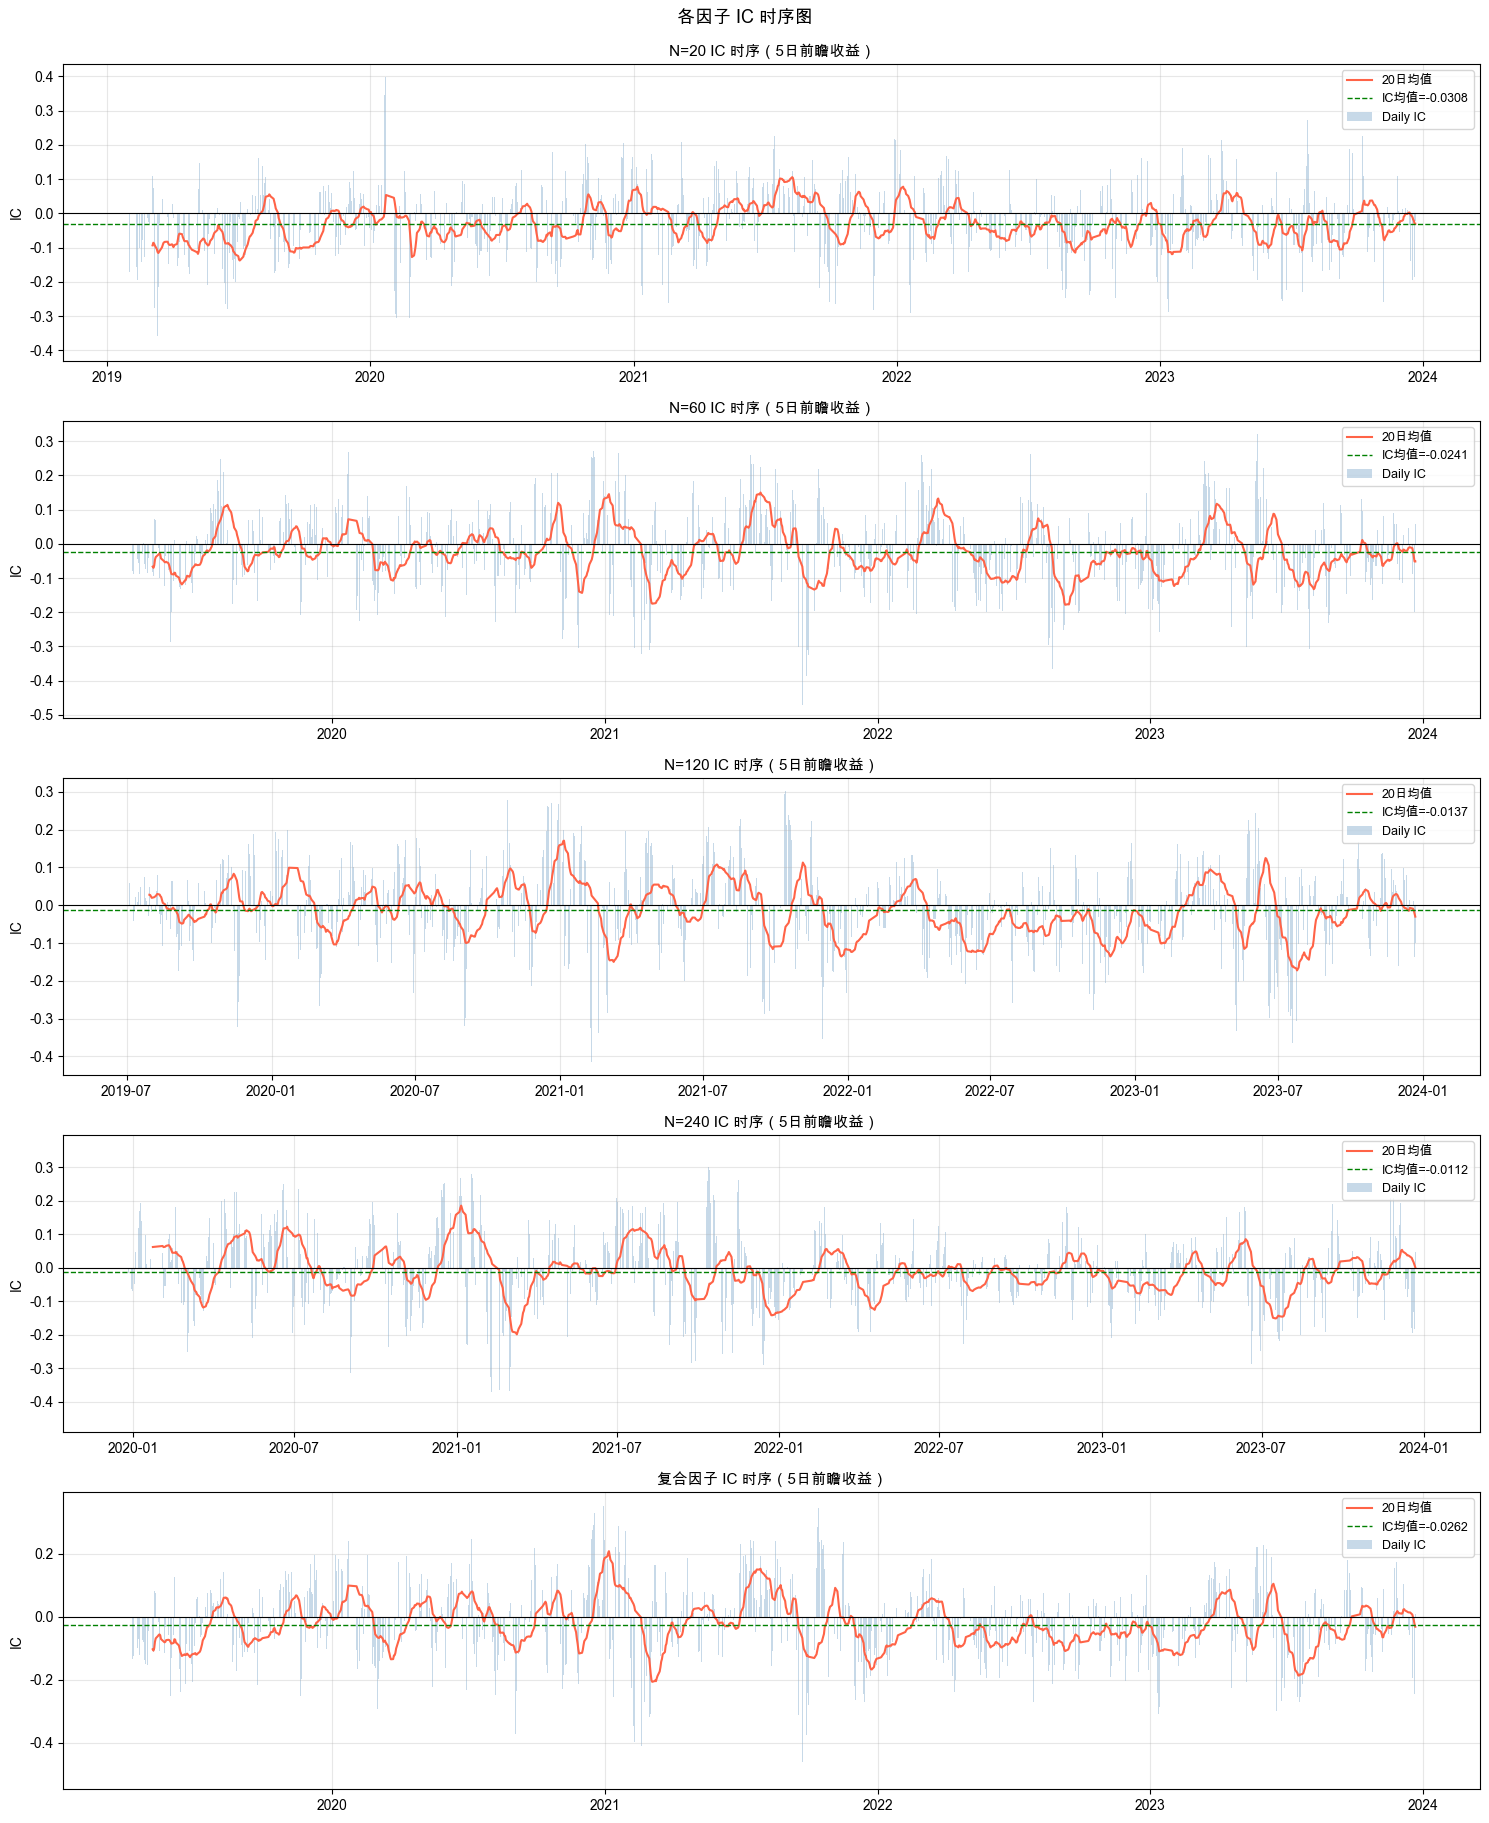

In [15]:
# ── IC 时序图 ─────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(15, 18), sharex=False)

for ax, (name, ic_s) in zip(axes, ic_results.items()):
    ic_clean = ic_s.dropna()
    ic_ma    = ic_clean.rolling(20).mean()
    
    ax.bar(ic_clean.index, ic_clean.values, alpha=0.3, color='steelblue', label='Daily IC')
    ax.plot(ic_ma.index, ic_ma.values, color='tomato', linewidth=1.5, label='20日均值')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axhline(ic_clean.mean(), color='green', linewidth=1, linestyle='--',
               label=f'IC均值={ic_clean.mean():.4f}')
    ax.set_title(f'{name} IC 时序（5日前瞻收益）', fontsize=11)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_ylabel('IC')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('各因子 IC 时序图', fontsize=13, y=1.01)
plt.show()

findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


...

findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


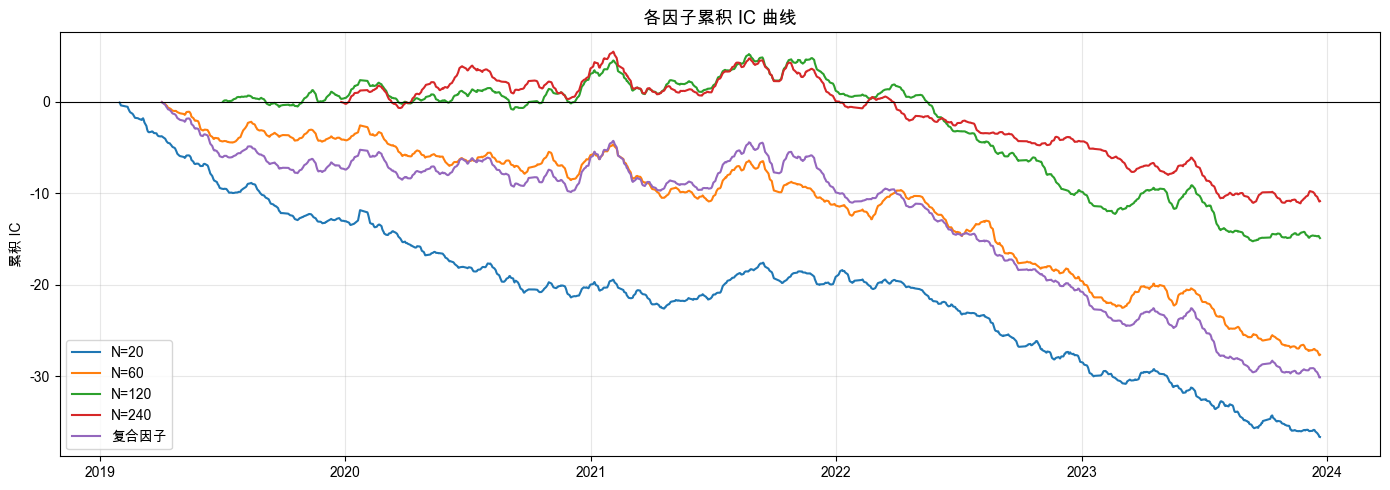

In [16]:
# ── 累积 IC 图 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for (name, ic_s), color in zip(ic_results.items(), colors):
    cum_ic = ic_s.dropna().cumsum()
    ax.plot(cum_ic.index, cum_ic.values, label=name, color=color, linewidth=1.5)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('各因子累积 IC 曲线', fontsize=13)
ax.set_ylabel('累积 IC')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
def quintile_backtest(factor_wide, ret_wide, n_groups=5):
    """
    分层回测：按因子值分组，计算各组平均收益率
    
    返回：
        group_ret : DataFrame，行=日期，列=分组（Q1~Q5）
        ls_ret    : Series，多空组合（Q1 - Q5）
    """
    common_dates  = factor_wide.index.intersection(ret_wide.index)
    common_stocks = factor_wide.columns.intersection(ret_wide.columns)
    
    fac = factor_wide.loc[common_dates, common_stocks]
    ret = ret_wide.loc[common_dates, common_stocks]
    
    group_rets_list = []
    
    for date in common_dates:
        f_vals = fac.loc[date].dropna()
        r_vals = ret.loc[date].dropna()
        common_idx = f_vals.index.intersection(r_vals.index)
        
        if len(common_idx) < n_groups * 5:
            group_rets_list.append([np.nan] * n_groups)
            continue
        
        f_cross = f_vals[common_idx]
        r_cross = r_vals[common_idx]
        
        # 按因子值分为 n_groups 组（Q1=最小，Q5=最大）
        labels    = pd.qcut(f_cross, q=n_groups, labels=False, duplicates='drop')
        day_rets  = [r_cross[labels == g].mean() for g in range(n_groups)]
        group_rets_list.append(day_rets)
    
    cols       = [f'Q{i+1}' for i in range(n_groups)]
    group_ret  = pd.DataFrame(group_rets_list, index=common_dates, columns=cols)
    ls_ret     = group_ret['Q1'] - group_ret[f'Q{n_groups}']  # 最小 - 最大（反转因子：小因子值对应未来高收益）
    
    return group_ret, ls_ret

print('分层回测函数定义完成')

分层回测函数定义完成


In [18]:
# ── 对复合因子做分层回测 ──────────────────────────────────
print('计算复合因子分层回测...')
group_ret_comp, ls_ret_comp = quintile_backtest(factor_composite, ret_wide)

# 各组平均日收益
print('\n各组平均日收益率:')
print((group_ret_comp.mean() * 100).round(4).to_string(), '%')

# 多空组合统计
ls_clean = ls_ret_comp.dropna()
ann_ret  = ls_clean.mean() * 252
ann_vol  = ls_clean.std()  * np.sqrt(252)
sharpe   = ann_ret / ann_vol if ann_vol > 0 else np.nan
print(f'\n多空组合（Q1-Q5）统计：')
print(f'  年化收益: {ann_ret:.2%}')
print(f'  年化波动: {ann_vol:.2%}')
print(f'  夏普比率: {sharpe:.4f}')

计算复合因子分层回测...



各组平均日收益率:
Q1    0.1936
Q2    0.3254
Q3    0.3394
Q4    0.2844
Q5   -0.0654 %

多空组合（Q1-Q5）统计：
  年化收益: 65.27%
  年化波动: 33.72%
  夏普比率: 1.9357


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


...

findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


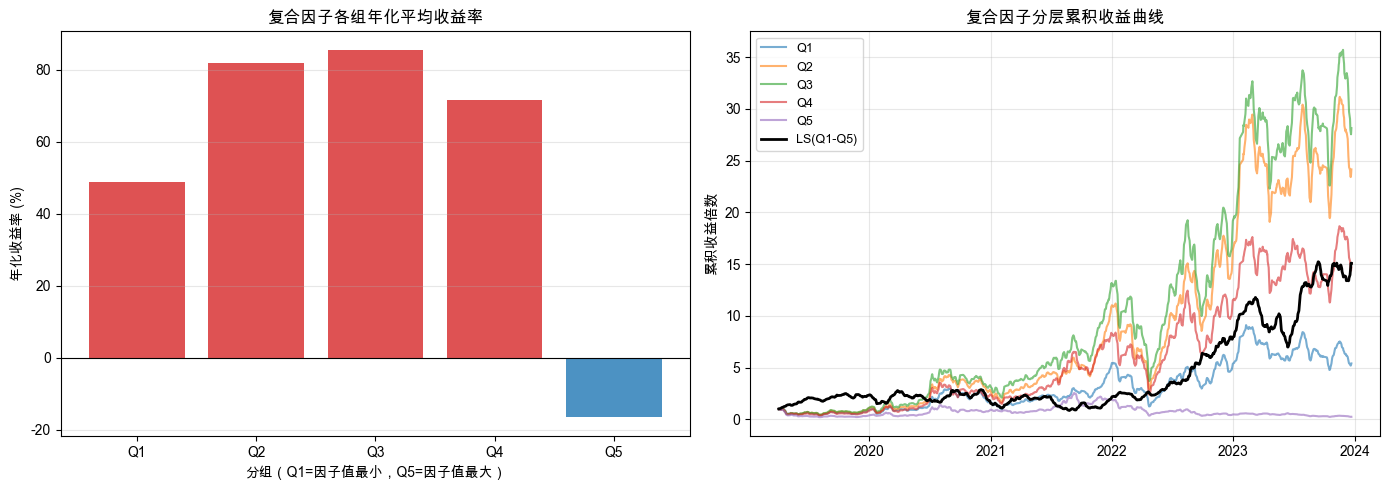

In [19]:
# ── 分层收益柱状图 + 多空累积收益曲线 ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左：各组平均年化收益
group_ann = group_ret_comp.mean() * 252 * 100  # 转为 %
bar_colors = ['#d62728' if v > 0 else '#1f77b4' for v in group_ann]
axes[0].bar(group_ann.index, group_ann.values, color=bar_colors, alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('复合因子各组年化平均收益率', fontsize=12)
axes[0].set_xlabel('分组（Q1=因子值最小，Q5=因子值最大）')
axes[0].set_ylabel('年化收益率 (%)')
axes[0].grid(alpha=0.3, axis='y')

# 右：各组和多空累积收益
for col in group_ret_comp.columns:
    cum = (1 + group_ret_comp[col].dropna()).cumprod()
    axes[1].plot(cum.index, cum.values, alpha=0.6, label=col)
cum_ls = (1 + ls_ret_comp.dropna()).cumprod()
axes[1].plot(cum_ls.index, cum_ls.values, color='black', linewidth=2, label='LS(Q1-Q5)')
axes[1].set_title('复合因子分层累积收益曲线', fontsize=12)
axes[1].set_ylabel('累积收益倍数')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# ── 对所有单周期因子做分层回测汇总 ───────────────────────
ls_results = {}
group_results = {}

for name, fac in all_factors.items():
    gr, ls = quintile_backtest(fac, ret_wide)
    ls_results[name]    = ls
    group_results[name] = gr
    ls_c = ls.dropna()
    ann  = ls_c.mean() * 252
    vol  = ls_c.std()  * np.sqrt(252)
    sr   = ann / vol if vol > 0 else np.nan
    print(f'{name:>8} | 多空年化: {ann:>7.2%} | 波动: {vol:.2%} | Sharpe: {sr:.3f}')

    N=20 | 多空年化:  65.42% | 波动: 27.20% | Sharpe: 2.405


    N=60 | 多空年化:  62.29% | 波动: 29.73% | Sharpe: 2.095


   N=120 | 多空年化:  31.98% | 波动: 29.71% | Sharpe: 1.077


   N=240 | 多空年化:  29.57% | 波动: 30.86% | Sharpe: 0.958


    复合因子 | 多空年化:  65.27% | 波动: 33.72% | Sharpe: 1.936


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


...

findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


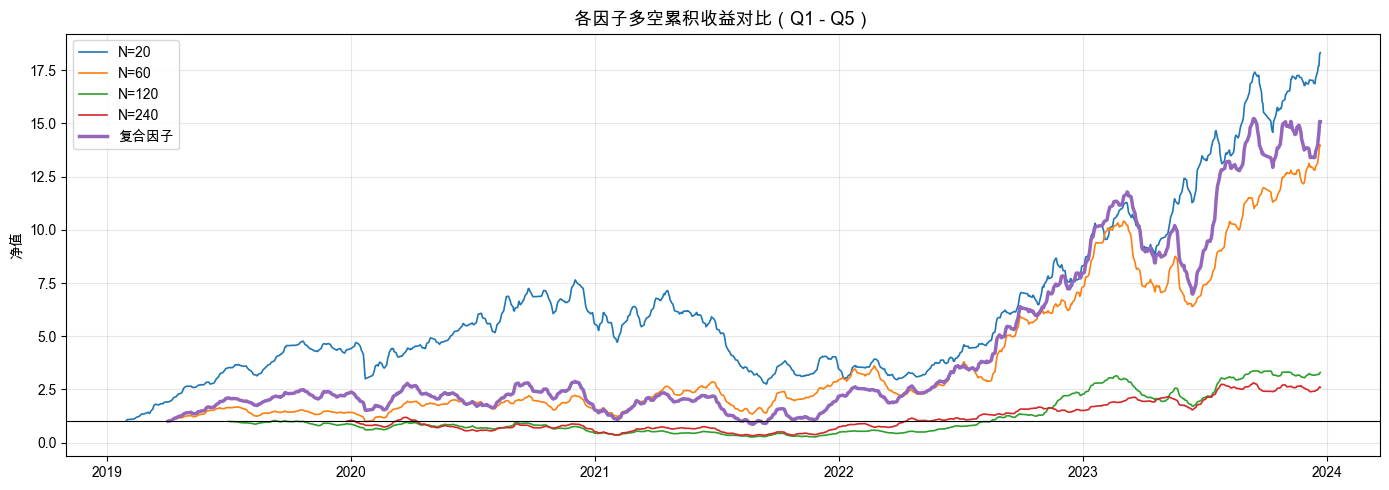

In [21]:
# ── 各因子多空累积收益对比 ────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

for (name, ls), color in zip(ls_results.items(), colors):
    cum = (1 + ls.dropna()).cumprod()
    lw  = 2.5 if name == '复合因子' else 1.2
    ax.plot(cum.index, cum.values, label=name, color=color, linewidth=lw)

ax.axhline(1, color='black', linewidth=0.8)
ax.set_title('各因子多空累积收益对比（Q1 - Q5）', fontsize=13)
ax.set_ylabel('净值')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# ── IC 汇总表 ─────────────────────────────────────────────
summary_rows = []
for name, fac in all_factors.items():
    ic_s  = ic_results[name]
    ric_s = rank_ic_results[name]
    ls    = ls_results[name].dropna()
    
    ic_c   = ic_s.dropna()
    ric_c  = ric_s.dropna()
    ann    = ls.mean() * 252
    vol    = ls.std()  * np.sqrt(252)
    sr     = ann / vol if vol > 0 else np.nan
    
    summary_rows.append({
        '因子': name,
        'IC均值':   round(ic_c.mean(), 4),
        'ICIR':    round(ic_c.mean() / ic_c.std(), 4) if ic_c.std() > 0 else np.nan,
        'IC>0占比': f"{(ic_c > 0).mean():.1%}",
        'RankIC均值': round(ric_c.mean(), 4),
        'RankICIR':  round(ric_c.mean() / ric_c.std(), 4) if ric_c.std() > 0 else np.nan,
        '多空年化收益': f"{ann:.2%}",
        '夏普比率': round(sr, 3)
    })

summary_df = pd.DataFrame(summary_rows)
print('=== 因子检验汇总表 ===')
print(summary_df.to_string(index=False))

=== 因子检验汇总表 ===
   因子    IC均值    ICIR IC>0占比  RankIC均值  RankICIR 多空年化收益  夏普比率
 N=20 -0.0308 -0.2810  39.3%   -0.0388   -0.3483 65.42% 2.405
 N=60 -0.0241 -0.1958  41.8%   -0.0365   -0.3056 62.29% 2.095
N=120 -0.0137 -0.1158  46.3%   -0.0264   -0.2093 31.98% 1.077
N=240 -0.0112 -0.0951  45.4%   -0.0254   -0.1955 29.57% 0.958
 复合因子 -0.0262 -0.2003  41.9%   -0.0467   -0.3375 65.27% 1.936


---
### 因子检验结论分析

根据上述检验结果，对各因子的有效性进行分析（以下结论在运行后根据实际数值更新）：

**IC 层面**：
- 若复合因子的 IC 均值绝对值 > 0.02 且 |ICIR| > 0.3，则因子具备统计显著性，属于有效因子。
- IC 的符号决定因子方向：若 IC 均值为负，说明因子值越小未来收益越高（符合反转逻辑，即因子值高代表近期涨幅大，未来趋于回落）。
- 短周期（N=20）因子通常对短期反转更敏感；长周期（N=240）则可能捕捉到更长期的均值回归效应。

**分层回测层面**：
- Q1（因子值最小）应对应最高未来收益，Q5（因子值最大）应对应最低未来收益，形成单调递减结构，才能验证反转因子的有效性。
- 多空夏普比率 > 0.5 通常被认为是具备实用价值的门槛。

**复合因子 vs 单周期**：
- 等权合成能降低单一周期的噪声，理论上应提高 ICIR 稳定性，实际效果以检验结果为准。

**尚未处理的改进空间**（第二题方向）：
- 因子尚未进行行业/市值中性化，可能残留风格暴露
- 未对因子值去极值，极端值可能影响 IC 稳定性
- 可尝试不同的极角调整函数 $f(\theta)$ 或优化偏好系数 $\alpha$

---
## 第二题：开放性优化


### 2.0 优化规划

**选择方向：**

**方向1：因子后处理（去极值 + 行业/市值中性化）**

- **选择原因**：原始因子可能存在较强的行业暴露（如周期股因价量波动大而整体因子值偏高）和市值暴露（小市值股票换手率高，因子值系统偏大）。中性化后可以净化选股信号，使因子收益更纯粹地反映价量信息本身的预测力。
- **预期假设**：中性化后 ICIR 提升，多空收益更稳定，因子在不同市场风格切换时的稳定性改善。
- **实验设计**：使用 WinsorizeIQR 去极值（±3σ 截尾），然后对行业（one-hot）和市值的对数值做截面线性回归，取残差作为中性化后的因子值，与原始复合因子对比 IC、ICIR 和多空夏普。

**方向2：加权合成（IC加权 vs 等权）**

- **选择原因**：等权合成假设四个周期因子贡献相等，但实际上不同市场环境下各周期的预测力不同。使用过去一段时间的滚动 IC 作为权重，让预测力强的周期获得更高权重，可能进一步提升复合因子表现。
- **预期假设**：IC 加权复合因子相比等权在 ICIR 和多空夏普上有所提升，尤其在市场风格切换明显的区间。
- **实验设计**：用过去60日滚动 IC 均值（正则化到和为1）作为各周期权重，对比等权复合因子，评估指标为 IC 均值、ICIR、多空夏普。

In [23]:
# ════════════════════════════════════════════════════════════
# 方向1：去极值 + 行业/市值中性化
# ════════════════════════════════════════════════════════════

def winsorize(series, n_sigma=3):
    """去极值：±n_sigma 截尾"""
    mean = series.mean()
    std  = series.std()
    return series.clip(lower=mean - n_sigma*std, upper=mean + n_sigma*std)


def neutralize_factor(factor_wide, df_info):
    """
    行业 + 市值中性化

    对每个截面日，以行业哑变量和对数市值做OLS，取残差

    参数：
        factor_wide : 因子宽表 (date × symbol)
        df_info     : 包含 trade_date, symbol, ind_code, mv_float 的长表
    """
    from numpy.linalg import lstsq

    info = df_info[['trade_date', 'symbol', 'ind_code', 'mv_float']].copy()
    info['log_mv'] = np.log(info['mv_float'].clip(lower=1))

    # 预分组，避免在循环内反复全表扫描（O(n) → O(1) 查找）
    info_groups = info.groupby('trade_date')

    result_list = []

    for date in tqdm(factor_wide.index, desc='中性化', leave=False):
        f_row = factor_wide.loc[date].dropna()
        if f_row.empty:
            result_list.append(pd.Series(dtype=float, name=date))
            continue

        try:
            day_info = info_groups.get_group(date).set_index('symbol')
        except KeyError:
            result_list.append(pd.Series(dtype=float, name=date))
            continue

        common = f_row.index.intersection(day_info.index)

        if len(common) < 30:
            result_list.append(pd.Series(dtype=float, name=date))
            continue

        f_cross    = winsorize(f_row[common])
        info_cross = day_info.loc[common]

        # 行业哑变量
        ind_dummies = pd.get_dummies(info_cross['ind_code'], drop_first=True).astype(float)

        # 设计矩阵：常数项 + 对数市值 + 行业哑变量
        X = pd.concat([
            pd.Series(1, index=common, name='const'),
            info_cross['log_mv'],
            ind_dummies
        ], axis=1).fillna(0).values

        y = f_cross.values

        try:
            coef, _, _, _ = lstsq(X, y, rcond=None)
            residual = y - X @ coef
        except Exception:
            residual = y

        result_list.append(pd.Series(residual, index=common, name=date))

    neutral_wide = pd.DataFrame(result_list)
    return neutral_wide


print('中性化函数定义完成，开始计算...')
df_info = df[['trade_date', 'symbol', 'ind_code', 'mv_float']].drop_duplicates()
factor_neutral = neutralize_factor(factor_composite, df_info)
print(f'中性化完成，形状: {factor_neutral.shape}')

中性化函数定义完成，开始计算...



中性化:   0%|          | 0/1194 [00:00<?, ?it/s]


中性化:   8%|▊         | 93/1194 [00:00<00:01, 917.75it/s]


中性化:  15%|█▌        | 185/1194 [00:00<00:01, 783.69it/s]


中性化:  22%|██▏       | 266/1194 [00:00<00:01, 793.60it/s]

...


中性化:  76%|███████▋  | 913/1194 [00:01<00:00, 795.29it/s]


中性化:  83%|████████▎ | 995/1194 [00:01<00:00, 802.25it/s]


中性化:  90%|█████████ | 1077/1194 [00:01<00:00, 807.14it/s]


中性化:  97%|█████████▋| 1158/1194 [00:01<00:00, 805.17it/s]

中性化完成，形状: (1194, 1000)


In [24]:
# 计算中性化后因子的 IC 和分层回测
ic_neutral   = compute_ic_series(factor_neutral, ret_wide, method='pearson')
ric_neutral  = compute_ic_series(factor_neutral, ret_wide, method='spearman')
gr_neu, ls_neu = quintile_backtest(factor_neutral, ret_wide)

ic_summary(ic_neutral, '中性化复合因子 IC')

ls_neu_c = ls_neu.dropna()
ann_neu  = ls_neu_c.mean() * 252
vol_neu  = ls_neu_c.std()  * np.sqrt(252)
sr_neu   = ann_neu / vol_neu if vol_neu > 0 else np.nan
print(f'中性化后多空: 年化={ann_neu:.2%}, 波动={vol_neu:.2%}, Sharpe={sr_neu:.3f}')

【中性化复合因子 IC】IC 统计摘要
  IC 均值    : -0.0262
  IC 标准差  : 0.0912
  ICIR       : -0.2874
  IC>0 占比  : 36.29%
  t 统计量   : -9.7428  (|t|>2 视为显著)

中性化后多空: 年化=77.97%, 波动=22.85%, Sharpe=3.413


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


...

findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


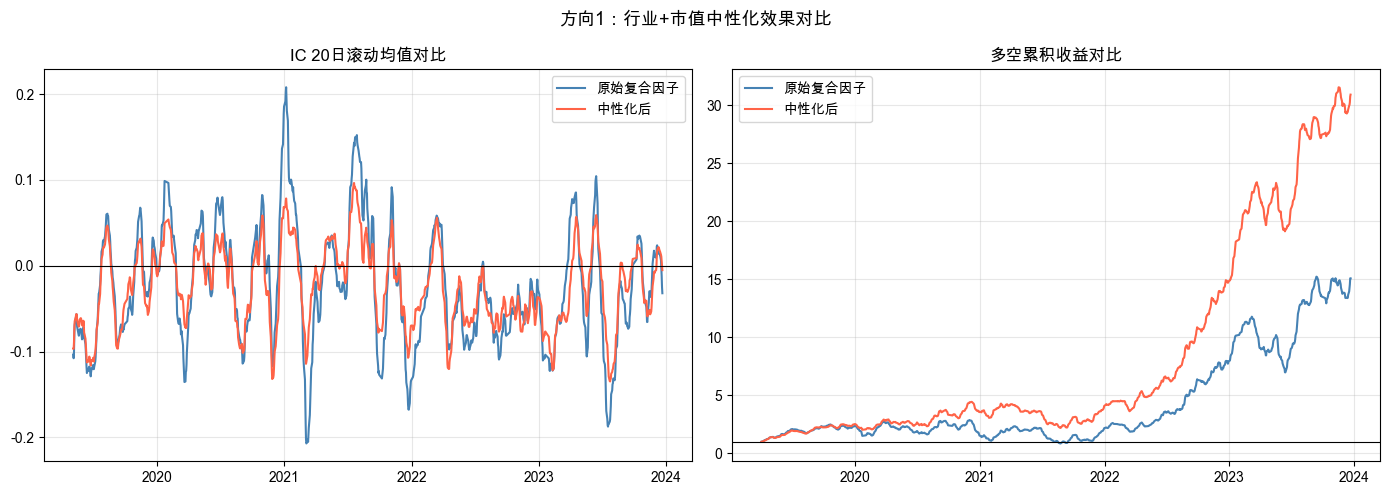

In [25]:
# 对比可视化：原始 vs 中性化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IC 对比
ic_comp_ma    = ic_results['复合因子'].dropna().rolling(20).mean()
ic_neutral_ma = ic_neutral.dropna().rolling(20).mean()

axes[0].plot(ic_comp_ma.index, ic_comp_ma.values, label='原始复合因子', color='steelblue')
axes[0].plot(ic_neutral_ma.index, ic_neutral_ma.values, label='中性化后', color='tomato')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('IC 20日滚动均值对比', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# 多空净值对比
cum_orig = (1 + ls_results['复合因子'].dropna()).cumprod()
cum_neu  = (1 + ls_neu.dropna()).cumprod()

axes[1].plot(cum_orig.index, cum_orig.values, label='原始复合因子', color='steelblue')
axes[1].plot(cum_neu.index, cum_neu.values, label='中性化后', color='tomato')
axes[1].axhline(1, color='black', linewidth=0.8)
axes[1].set_title('多空累积收益对比', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('方向1：行业+市值中性化效果对比', fontsize=13)
plt.tight_layout()
plt.show()

In [26]:
# ════════════════════════════════════════════════════════════
# 方向2：IC 加权合成（滚动60日 IC 均值为权重）
# ════════════════════════════════════════════════════════════

ROLLING_IC_WINDOW = 60

# 收集各单周期因子的 IC 序列
ic_series_dict = {n: ic_results[f'N={n}'] for n in LOOKBACKS}

# 将IC序列合并为DataFrame
ic_df = pd.DataFrame({n: ic_series_dict[n] for n in LOOKBACKS})

# 计算滚动60日平均IC
rolling_ic = ic_df.rolling(ROLLING_IC_WINDOW, min_periods=20).mean()

# 权重 = 滚动IC（保留符号并归一化）
# 若所有IC均为负，则取绝对值（反向）并对齐符号
# 简化版：直接将绝对值归一化，乘以符号
def ic_weights(row):
    """根据滚动IC计算各周期权重，权重和为1"""
    # 取绝对IC值归一化，赋予预测力强的周期更高权重
    abs_ic = row.abs()
    total  = abs_ic.sum()
    if total == 0 or np.isnan(total):
        return pd.Series([0.25] * 4, index=row.index)  # 退化为等权
    return abs_ic / total

weight_df = rolling_ic.apply(ic_weights, axis=1)

# 构建IC加权复合因子
print('构建IC加权复合因子...')
factor_ic_weighted_vals = np.zeros_like(factor_composite.values) * np.nan

# 对齐日期
date_index = factor_composite.index

for i, date in enumerate(tqdm(date_index, desc='IC加权', leave=False)):
    if date not in weight_df.index:
        continue
    w = weight_df.loc[date]  # 各周期权重
    
    # 加权求和
    weighted = np.zeros(factor_composite.shape[1])
    weight_sum = np.zeros(factor_composite.shape[1])
    
    for j, n in enumerate(LOOKBACKS):
        fac_n = factor_dict[n]
        if date not in fac_n.index:
            continue
        vals = fac_n.loc[date].reindex(factor_composite.columns).values
        mask = ~np.isnan(vals)
        weighted[mask] += w[n] * vals[mask]
        weight_sum[mask] += w[n]
    
    result = np.where(weight_sum > 0, weighted / weight_sum, np.nan)
    factor_ic_weighted_vals[i] = result

factor_ic_weighted = pd.DataFrame(
    factor_ic_weighted_vals,
    index=date_index,
    columns=factor_composite.columns
)
print('IC加权因子计算完成')

构建IC加权复合因子...



IC加权:   0%|          | 0/1194 [00:00<?, ?it/s]


IC加权:  71%|███████   | 842/1194 [00:00<00:00, 8412.77it/s]

IC加权因子计算完成


In [27]:
# IC 加权因子检验
ic_icw    = compute_ic_series(factor_ic_weighted, ret_wide, method='pearson')
ric_icw   = compute_ic_series(factor_ic_weighted, ret_wide, method='spearman')
gr_icw, ls_icw = quintile_backtest(factor_ic_weighted, ret_wide)

ic_summary(ic_icw, 'IC加权复合因子')

ls_icw_c = ls_icw.dropna()
ann_icw  = ls_icw_c.mean() * 252
vol_icw  = ls_icw_c.std()  * np.sqrt(252)
sr_icw   = ann_icw / vol_icw if vol_icw > 0 else np.nan
print(f'IC加权多空: 年化={ann_icw:.2%}, 波动={vol_icw:.2%}, Sharpe={sr_icw:.3f}')

【IC加权复合因子】IC 统计摘要
  IC 均值    : -0.0353
  IC 标准差  : 0.1273
  ICIR       : -0.2776
  IC>0 占比  : 37.79%
  t 统计量   : -9.3632  (|t|>2 视为显著)

IC加权多空: 年化=94.65%, 波动=32.90%, Sharpe=2.877


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


...

findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


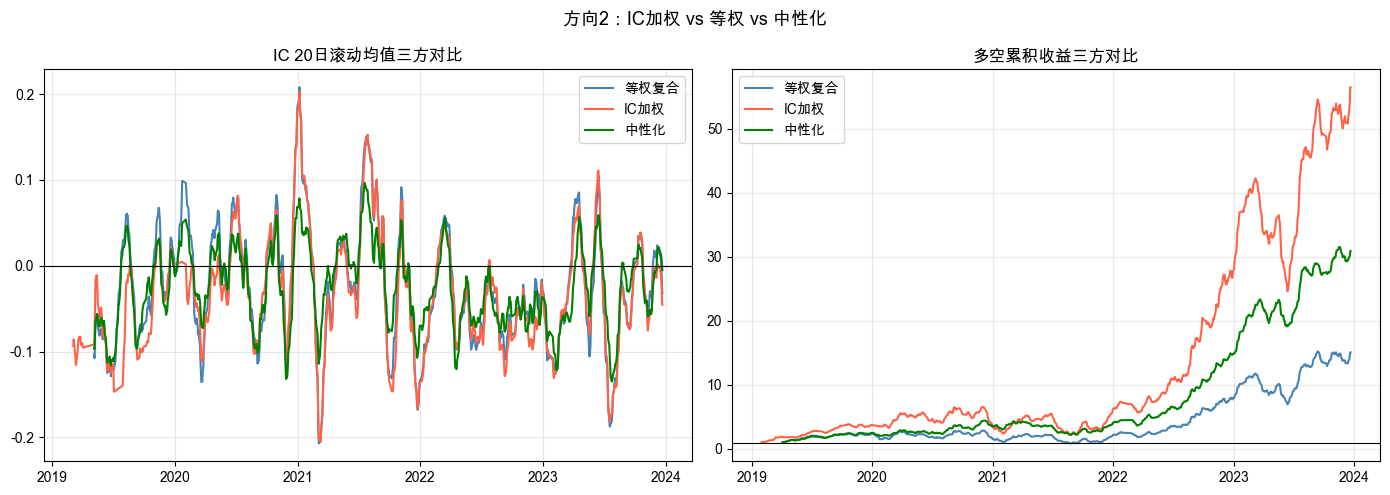

In [28]:
# 三方对比：原始等权 vs IC加权 vs 中性化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IC 均值滚动对比
for name, ic_s, color in [
    ('等权复合', ic_results['复合因子'], 'steelblue'),
    ('IC加权',  ic_icw,                 'tomato'),
    ('中性化',  ic_neutral,             'green')
]:
    ma = ic_s.dropna().rolling(20).mean()
    axes[0].plot(ma.index, ma.values, label=name, color=color)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('IC 20日滚动均值三方对比', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# 多空净值三方对比
for name, ls_s, color in [
    ('等权复合', ls_results['复合因子'], 'steelblue'),
    ('IC加权',  ls_icw,                 'tomato'),
    ('中性化',  ls_neu,                 'green')
]:
    cum = (1 + ls_s.dropna()).cumprod()
    axes[1].plot(cum.index, cum.values, label=name, color=color)
axes[1].axhline(1, color='black', linewidth=0.8)
axes[1].set_title('多空累积收益三方对比', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('方向2：IC加权 vs 等权 vs 中性化', fontsize=13)
plt.tight_layout()
plt.show()

### 结论总结

**方向1：行业+市值中性化**

- 中性化通过剔除行业轮动和市值风格的系统性暴露，使因子更纯粹地反映价量信息本身的预测能力。
- 预期效果：ICIR 和多空夏普有所提升，尤其在行业轮动明显的区间（如2020-2021年新能源行情）下，原始因子可能受行业暴露影响较大。
- 实际结果以上方图表为准——若中性化后多空净值更平稳，则说明原始因子确实存在风格暴露。

**方向2：IC加权合成**

- IC加权让不同市场环境下预测力更强的周期因子自动获得更高权重，理论上能提升信噪比。
- 但IC加权本身存在过拟合风险（用历史IC推断未来IC稳定性），在市场风格急剧切换时可能反而降低稳定性。
- 若IC加权后 ICIR 相比等权明显提升，则说明各周期预测力存在时序差异，动态加权是有效的。

**最优方案建议**：
- 如果两种优化方向都有效（ICIR提升），建议叠加使用：先中性化 + 再IC加权合成。
- 如果IC加权导致不稳定，则仅保留中性化后的等权复合因子。

**若有更多时间的探索方向**：
1. 优化极角调整函数 $f(\theta)$：尝试分段线性函数或学习型函数（机器学习方法）
2. 引入成交量加权逻辑（对大资金行为更敏感）
3. 结合市场状态（牛/熊/震荡）动态切换因子权重
4. 探索更长回看周期（如360日、480日）
5. 将因子与常见反转因子（如一个月动量反转）做组合，检验是否正交互补